In [144]:
import numpy as np
import pandas as pd
import keras
import matplotlib.pyplot as plt
from keras import layers
import openpyxl as xl
from openpyxl.styles import Font
import os

In [145]:
#Coletando dados

df = pd.read_excel('/Users/PC/Documents/Proj_MPA/Recontrucao/Sergipe/2-Sciaenidae/R.xlsx')



#Dados iniciais
df_especies = df[['Ano',"Pescadinha_art", "Tortinha_art", "Pesc_banana_art"]].dropna().reset_index(drop=True)
anos_Sergipe_prever = np.array([*range(1962,1965),*range(1966,1970),*range(1974,1990),*range(1995,2008),*range(2010,2017),*range(2018,2023)])

lista_de_prop=[] #lista onde ficam os arrays com as proporções Sergipe cada especie
especies = df_especies.drop('Ano',axis=1).columns.to_numpy() #lista das especies

#Coluna da soma
for i in range(len(df_especies['Ano'])):
  df_especies.loc[i,'Soma'] = df_especies.iloc[i,1:].sum() 


for k in range(len(especies)):

     dados = df_especies[['Ano',especies[k],'Soma']]
     
     #Fazendo as proporções de cada especie em relação à soma
     for i in range(len(dados['Ano'])):
       if dados.loc[i,'Soma']!=0:
           dados.loc[i,'Prop_'+especies[k]] = dados.loc[i,especies[k]] / dados.loc[i,'Soma']
     
     
     anos_com_dados = dados["Ano"].values
     todos_anos = np.concatenate((anos_Sergipe_prever, anos_com_dados))
     todos_anos.sort()
     
     prop= dados['Prop_'+especies[k]].values
     lista_de_prop.append(prop)
     print(dados.head())



    Ano  Pescadinha_art       Soma  Prop_Pescadinha_art
0  1962        0.183049  10.408599             0.017586
1  1963        0.179460  17.602283             0.010195
2  1964        0.183049  11.412304             0.016040
3  1966        0.204584   5.408659             0.037825
4  1967        0.215352   1.467197             0.146778
    Ano  Tortinha_art       Soma  Prop_Tortinha_art
0  1962      9.912873  10.408599           0.952373
1  1963     17.116277  17.602283           0.972390
2  1964     10.916579  11.412304           0.956562
3  1966      4.854612   5.408659           0.897563
4  1967      0.883990   1.467197           0.602503
    Ano  Pesc_banana_art       Soma  Prop_Pesc_banana_art
0  1962         0.312677  10.408599              0.030040
1  1963         0.306546  17.602283              0.017415
2  1964         0.312677  11.412304              0.027398
3  1966         0.349462   5.408659              0.064612
4  1967         0.367855   1.467197              0.250720


C:\Users\PC\AppData\Local\Temp\ipykernel_2244\2496826612.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dados.loc[i,'Prop_'+especies[k]] = dados.loc[i,especies[k]] / dados.loc[i,'Soma']
C:\Users\PC\AppData\Local\Temp\ipykernel_2244\2496826612.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dados.loc[i,'Prop_'+especies[k]] = dados.loc[i,especies[k]] / dados.loc[i,'Soma']
C:\Users\PC\AppData\Local\Temp\ipykernel_2244\2496826612.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy o

In [146]:
#Normalização dos dados
ano_mean = np.mean(anos_com_dados)
ano_std = np.std(anos_com_dados)
anos_Sergipe_prever_norm = (anos_Sergipe_prever - ano_mean)/ano_std
anos_com_dados_norm = (anos_com_dados - ano_mean)/ano_std

lista_prop_norm=[]  #lista com as proporçãoes normalizads Sergipe cada especie

lista_prop_mean=[]  #listas Sergipe aplicar a inversa da normalização
lista_prop_std=[]

for k in range(len(lista_de_prop)):
    prop_mean = np.mean(lista_de_prop[k])
    prop_std = np.std(lista_de_prop[k])
    prop_norm = (lista_de_prop[k] - prop_mean)/prop_std

    lista_prop_norm.append(prop_norm)
    lista_prop_mean.append(prop_mean)
    lista_prop_std.append(prop_std)

print(lista_prop_norm)


[array([-1.40484679, -1.44905049, -1.41409717, -1.28380365, -0.63219285,
       -0.63219285, -0.63219285, -0.63219285, -0.63219285, -0.63219285,
       -1.19053695,  1.16675707,  1.70933874,  0.67390695,  1.06959225,
        0.14830545, -1.33252688, -1.39953165, -1.36199256, -1.34714571,
       -1.39070213, -1.32047273, -1.43250741, -0.93492629,  0.23398055,
        0.19358647,  0.21976239,  0.18396569,  0.33047471,  1.19980963,
        0.30415065,  0.39786247, -0.07077294,  0.71219717,  0.70551283,
        1.13693869,  0.52477714,  0.55656336,  0.79844011,  0.4063533 ,
        0.71046485,  0.72838616,  1.88013416,  0.38386546,  0.99944878,
        1.28217415,  1.72383755,  0.74548376]), array([ 1.64579304,  1.72763817,  1.66292053,  1.42167628,  0.21518982,
        0.21518982,  0.21518982,  0.21518982,  0.21518982,  0.21518982,
       -1.35178173, -1.03964093, -1.4064135 , -0.4832425 , -0.78284565,
        0.15001311,  1.51188951,  1.63595183,  1.56644652,  1.53895692,
        1.61960

In [147]:
#Criação das pastas onde serão armazenados os pesos
for esp in especies:
    folder_path = f'/Users/PC/Documents/Proj_MPA/Recontrucao/Sergipe/2-Sciaenidae/Desagregação/Pescadinha_total_art/pesos prop {esp}'
    os.makedirs(folder_path, exist_ok=True) 


#Função Sergipe fazer o Fit do modelo e salvar seus pesos Sergipe cada especie
def Fit_das_proporcoes(anos_com_dados_norm,
                       lista_prop_norm,
                       lista_de_epocas,
                       lista_de_otimizadores,
                       lista_de_overwrite,
                       especies):
    
    model = keras.Sequential([layers.Dense(96,activation='leaky_relu',input_shape=(1,)),
                                 layers.Dense(32,activation='leaky_relu'),
                                 layers.Dense(80,activation='leaky_relu'),
                                 layers.Dense(80,activation='leaky_relu'),
                                 layers.Dense(96,activation='leaky_relu'),
                                 layers.Dense(112,activation='leaky_relu'),
                                 layers.Dense(1,activation='linear')])
    
    lista_de_loss=[]
    for k in range(len(especies)):
        opt =  lista_de_otimizadores[k]            #keras.optimizers.Nadam(learning_rate=0.001)
        model.compile(optimizer=opt, loss='mse')
        
        
        history = model.fit(anos_com_dados_norm,lista_prop_norm[k], epochs=lista_de_epocas[k], verbose=0)
        lista_de_loss.append(history.history['loss'])

        
        model.save_weights(f'/Users/PC/Documents/Proj_MPA/Recontrucao/Sergipe/2-Sciaenidae/Desagregação/Pescadinha_total_art/pesos prop {especies[k]}/.weights.h5', overwrite=lista_de_overwrite[k])
    return model,lista_de_loss

In [148]:
#Fit do modelo
Nadam= keras.optimizers.Nadam(learning_rate=0.001)
Adam= keras.optimizers.Adam(learning_rate=0.001)

lista_de_epocas=[25,25,25,25,25,25,25,25,25]
lista_de_otimizadores=[Adam,Adam,Adam,Adam,Adam,Adam,Adam,Adam,Adam]
lista_de_overwrite = [True,True,True,True,True,True,True,True,True]
model,lista_de_loss = Fit_das_proporcoes(anos_com_dados_norm,
                                         lista_prop_norm,
                                         lista_de_epocas,
                                         lista_de_otimizadores,
                                         lista_de_overwrite,
                                         especies)



c:\Users\PC\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [149]:
#Previsões Sergipe cada especie
lista_de_previsoes=[]
lista_fits=[]

p = np.linspace(-2,2,50)
for k in range(len(especies)):
    
    model.load_weights(f'/Users/PC/Documents/Proj_MPA/Recontrucao/Sergipe/2-Sciaenidae/Desagregação/Pescadinha_total_art/pesos prop {especies[k]}/.weights.h5')

    prev_ausentes = model.predict(anos_Sergipe_prever_norm)*lista_prop_std[k] + lista_prop_mean[k]
    fit = model.predict(p)*lista_prop_std[k] + lista_prop_mean[k]
    #Colocando valores negativos Sergipe 0 e proporções no maximo 1
    for i in range(len(prev_ausentes)):
        if prev_ausentes[i]<0:
            prev_ausentes[i]=0
        if prev_ausentes[i]>1:
            prev_ausentes[i]=1

    lista_de_previsoes.append(prev_ausentes)
    lista_fits.append(fit)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


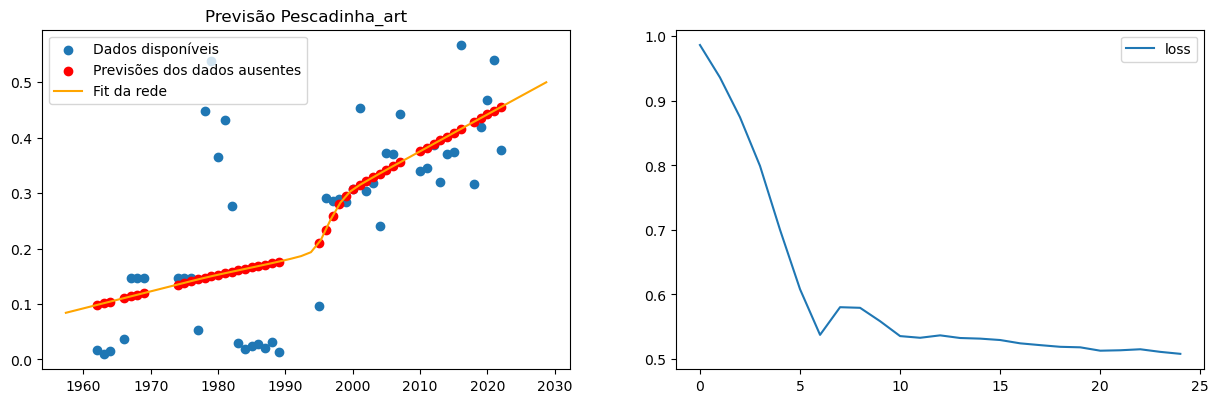

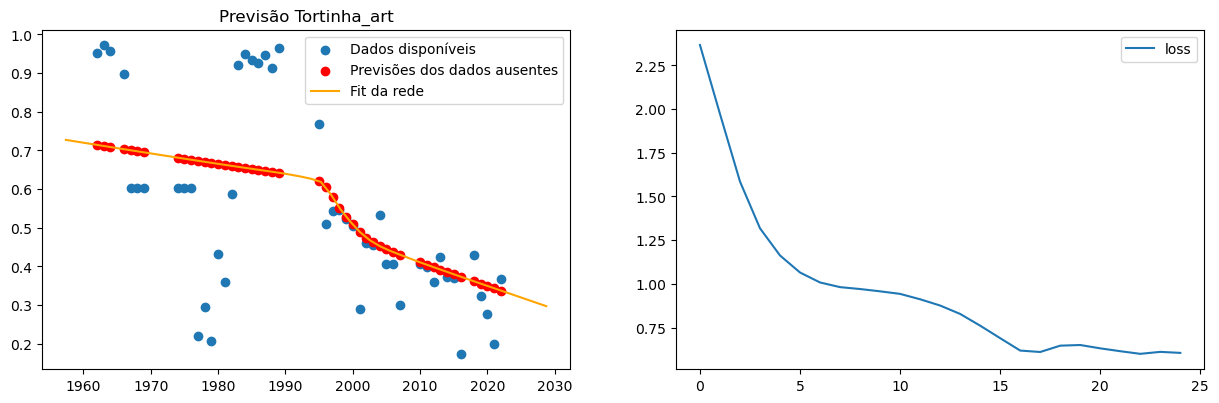

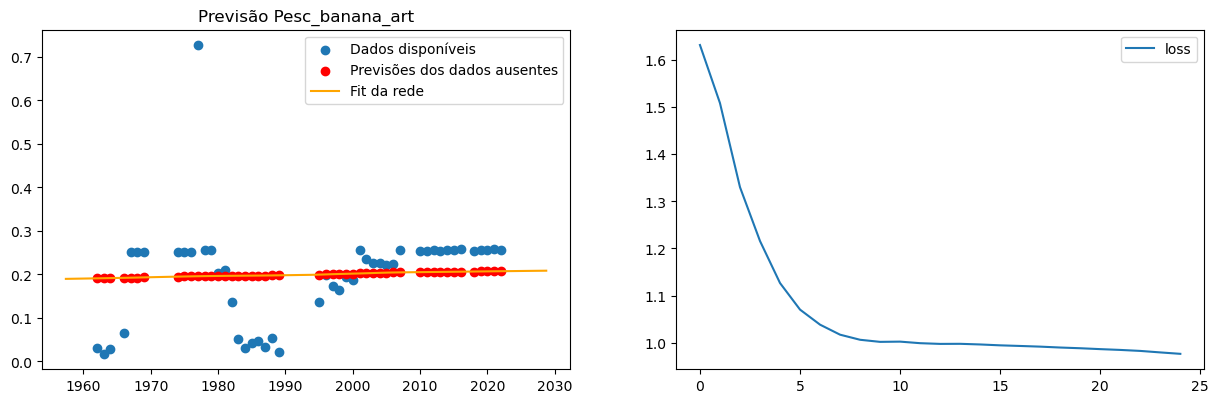

In [150]:
#Plot das previsoes e loss Sergipe cada especie
for k in range(len(especies)):
    plt.figure(figsize=(15,5*len(especies)))
    plt.subplot(len(especies),2,2*k+1 ).scatter(anos_com_dados,lista_de_prop[k],label='Dados disponíveis')
    plt.subplot(len(especies),2,2*k+1 ).scatter(anos_Sergipe_prever,lista_de_previsoes[k], color='red', label='Previsões dos dados ausentes')
    plt.subplot(len(especies),2,2*k+1 ).plot(p*ano_std + ano_mean,lista_fits[k],color='orange',label='Fit da rede')
    plt.title(f'Previsão {especies[k]}')
    plt.legend()

    plt.subplot(len(especies),2,2*k+2).plot(lista_de_loss[k],label='loss')
    plt.legend()

plt.show()

In [151]:
#Lista de anos sem buracos normalizada e sua predição      (Sergipe poder me referir por indices)
anos = np.arange(1950,np.max(anos_Sergipe_prever)+1)
anos_norm = (anos-ano_mean)/ano_std

#Previsoes sem buracos Sergipe cada especie
lista_prev_continua=[]
for k in range(len(especies)):
    model.load_weights(f'/Users/PC/Documents/Proj_MPA/Recontrucao/Sergipe/2-Sciaenidae/Desagregação/Pescadinha_total_art/pesos prop {especies[k]}/.weights.h5')
    prev_continua = model.predict(anos_norm)*lista_prop_std[k] + lista_prop_mean[k]
    
    for i in range(len(prev_continua)):
        if prev_continua[i]<0:
            prev_continua[i]=0
        if prev_continua[i]>=1:
            prev_continua[i]=1
    
    lista_prev_continua.append(prev_continua.flatten())
  


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [152]:
#Soma das proporções
prop_soma = np.zeros(len(anos))
for k in range(len(especies)):
    prop_soma+=lista_prev_continua[k]

#Dividindo proporções pela soma Sergipe que de sempre 1
for k in range(len(especies)):
  lista_prev_continua[k] /= prop_soma 
print(lista_prev_continua[1])

[0.74975765 0.74661297 0.7434658  0.74031556 0.7371649  0.734002
 0.730833   0.7276427  0.72446316 0.72128814 0.7181057  0.7149271
 0.71174514 0.7085659  0.7053959  0.7022305  0.6990619  0.695889
 0.6927051  0.6895091  0.68631196 0.6831214  0.67994565 0.67679274
 0.6736581  0.67053163 0.6674371  0.6643562  0.6613843  0.6584986
 0.6557159  0.65301424 0.6503478  0.6477056  0.6450719  0.6424525
 0.6398338  0.6372025  0.63451695 0.63174903 0.6288554  0.6258248
 0.62256694 0.6189541  0.6132935  0.6028849  0.5822598  0.5577382
 0.5345074  0.51537466 0.5003449  0.48675764 0.47529745 0.46526834
 0.45639062 0.44853547 0.44144353 0.43453908 0.4277186  0.4209215
 0.41419992 0.4076741  0.4011889  0.39471465 0.38826567 0.38181928
 0.3753975  0.3690221  0.3626989  0.35638663 0.35008594 0.3437996
 0.33753198]


In [153]:
#Dicionario dos indices das espécie Sergipe prever e da que será desagregada
especies_com_desagregada = np.append(especies,"Pescadinha_total_art") 
todas_colunas=df.columns.to_numpy()
dic_especies={}
for k in range(len(especies_com_desagregada)):
    for i in range(len(todas_colunas)):
        if especies_com_desagregada[k]==todas_colunas[i]:
            dic_especies[especies_com_desagregada[k]]=i+1 #Índices do openpyxl
            break
print(dic_especies)

{'Pescadinha_art': 25, 'Tortinha_art': 27, 'Pesc_banana_art': 29, 'Pescadinha_total_art': 24}


In [154]:
#Adicionando novos dados na planilha e colorindo
wb = xl.load_workbook('/Users/PC/Documents/Proj_MPA/Recontrucao/Sergipe/2-Sciaenidae/R.xlsx')
ws=wb.active

for k in range(len(especies)):
    for i in range(len(anos)):
        celula=ws.cell(anos[i]-1950+2 , dic_especies[especies[k]])
        
        #Dados desagregados Sergipe células com valores mantém a cor
        if i+1950 in anos_Sergipe_prever and pd.isnull(celula.value)==False:   
          celula.value += ws.cell(anos[i]-1950+2, dic_especies["Pescadinha_total_art"]).value*lista_prev_continua[k][i]
          celula.font = Font(color=celula.font.color,name='Calibri')


        #Dados desagregados Sergipe celulas vazias são colocados em vermelho
        if i+1950 in anos_Sergipe_prever and pd.isnull(celula.value)==True:
          celula.value = ws.cell(anos[i]-1950+2, dic_especies["Pescadinha_total_art"]).value*lista_prev_continua[k][i]
          celula.font = Font(color='FFFF0000',name='Calibri')
          

      

wb.save('Desag_Pescadinha_total_art.xlsx')